In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
DATA_DIR = Path("traffic_sign")

TRAIN_CSV = DATA_DIR / "Train.csv"
TEST_CSV = DATA_DIR / "Test.csv"
META_CSV = DATA_DIR / "Meta.csv"

print("DATA_DIR ekziston:", DATA_DIR.exists())
print("Train.csv ekziston:", TRAIN_CSV.exists())
print("Test.csv ekziston:", TEST_CSV.exists())
print("Meta.csv ekziston:", META_CSV.exists())

DATA_DIR ekziston: True
Train.csv ekziston: True
Test.csv ekziston: True
Meta.csv ekziston: True


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
meta_df = pd.read_csv(META_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Meta shape:", meta_df.shape)

train_df.head()

Train shape: (39209, 8)
Test shape: (12630, 8)
Meta shape: (43, 5)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [6]:
print("Kolonat ne Train.csv:")
print(train_df.columns.tolist())

print("Vlera mungese ne train:")
print(train_df.isnull().sum())

print("Numri i klasave:", train_df['ClassId'].nunique())
print("Shperndarja e klasave:")
print(train_df['ClassId'].value_counts().sort_index())

Kolonat ne Train.csv:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Vlera mungese ne train:
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64
Numri i klasave: 43
Shperndarja e klasave:
ClassId
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64


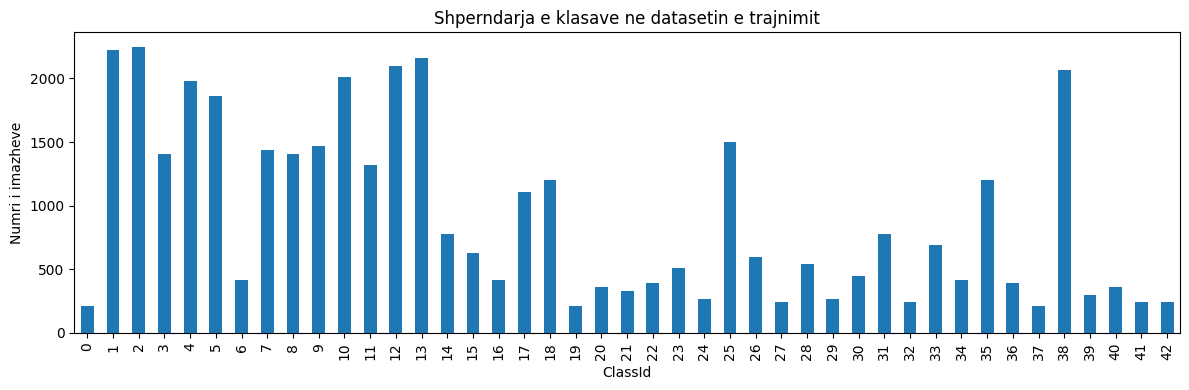

In [7]:
plt.figure(figsize=(12, 4))
train_df['ClassId'].value_counts().sort_index().plot(kind='bar')
plt.title('Shperndarja e klasave ne datasetin e trajnimit')
plt.xlabel('ClassId')
plt.ylabel('Numri i imazheve')
plt.tight_layout()
plt.show()

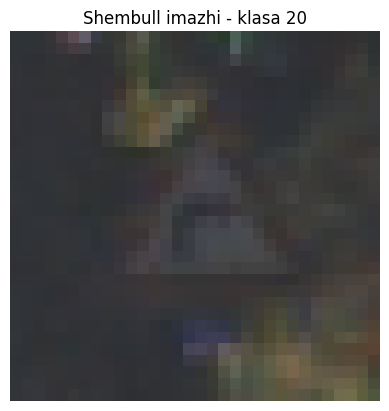

In [8]:
IMG_SIZE = 32

def load_image(relative_path, img_size=IMG_SIZE):
    image_path = DATA_DIR / relative_path
    image = Image.open(image_path).convert('RGB')
    image = image.resize((img_size, img_size))
    return np.array(image) / 255.0

# Testim me nje imazh
sample_path = train_df.iloc[0]['Path']
sample_img = load_image(sample_path)

plt.imshow(sample_img)
plt.title(f"Shembull imazhi - klasa {train_df.iloc[0]['ClassId']}")
plt.axis('off')
plt.show()

In [9]:
USE_SUBSET = True
SUBSET_SIZE = 8000

if USE_SUBSET:
    train_work_df = train_df.sample(
        n=min(SUBSET_SIZE, len(train_df)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
else:
    train_work_df = train_df.copy()

print("Numri i imazheve qe do perdoren:", len(train_work_df))
print("Numri i klasave:", train_work_df['ClassId'].nunique())

Numri i imazheve qe do perdoren: 8000
Numri i klasave: 43


In [10]:
X_images = np.array([load_image(path) for path in train_work_df['Path']])
y = train_work_df['ClassId'].values

print("Forma e X_images:", X_images.shape)
print("Forma e y:", y.shape)

Forma e X_images: (8000, 32, 32, 3)
Forma e y: (8000,)


In [11]:
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_images,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train_img.shape, y_train.shape)
print("Test:", X_test_img.shape, y_test.shape)

Train: (6400, 32, 32, 3) (6400,)
Test: (1600, 32, 32, 3) (1600,)


In [12]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

print("X_train_flat:", X_train_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (6400, 3072)
X_test_flat: (1600, 3072)


In [13]:
pca = PCA(n_components=100, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Forma pas PCA:", X_train_pca.shape)
print("Varianca e ruajtur nga PCA:", round(pca.explained_variance_ratio_.sum(), 4))

Forma pas PCA: (6400, 100)
Varianca e ruajtur nga PCA: 0.9464


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [15]:
results = []
trained_models = {}

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })
    trained_models[model_name] = model

    print(f"===== {model_name} =====")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred

In [16]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=3, scoring='f1_macro', n_jobs=-1)
knn_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per KNN:", knn_grid.best_params_)
y_pred_knn = evaluate_model('KNN + PCA', knn_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per KNN: {'knn__n_neighbors': 3, 'knn__weights': 'distance'}
===== KNN + PCA =====
Accuracy: 0.7744
Precision: 0.802
Recall: 0.7661
F1-score: 0.7746
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.74      0.62      0.68        96
           2       0.81      0.59      0.68        92
           3       0.62      0.70      0.66        60
           4       0.69      0.86      0.76        86
           5       0.47      0.62      0.54        68
           6       0.65      0.76      0.70        17
           7       0.49      0.61      0.55        57
           8       0.58      0.86      0.69        59
           9       0.91      0.69      0.79        62
          10       0.81      0.82      0.81        72
          11       0.85      0.69      0.76        49
          12       0.93      0.87      0.90        93
          13       0.94      0.91      0.93      

In [17]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train_flat, y_train)

print("Parametrat me te mire per Random Forest:", rf_grid.best_params_)
y_pred_rf = evaluate_model('Random Forest', rf_grid.best_estimator_, X_train_flat, X_test_flat, y_train, y_test)


Parametrat me te mire per Random Forest: {'max_depth': None, 'n_estimators': 200}
===== Random Forest =====
Accuracy: 0.9175
Precision: 0.9461
Recall: 0.8851
F1-score: 0.9067
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.78      0.94      0.85        96
           2       0.78      0.88      0.83        92
           3       0.82      0.85      0.84        60
           4       0.88      0.95      0.92        86
           5       0.79      0.68      0.73        68
           6       0.94      1.00      0.97        17
           7       0.98      0.82      0.90        57
           8       0.94      0.81      0.87        59
           9       0.97      1.00      0.98        62
          10       0.97      0.96      0.97        72
          11       0.91      1.00      0.95        49
          12       0.98      0.98      0.98        93
          13       0.97      1.00      0.98  

In [18]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_params = {
    'lr__C': [0.1, 1, 10]
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per Logistic Regression:", lr_grid.best_params_)
y_pred_lr = evaluate_model('Logistic Regression + PCA', lr_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per Logistic Regression: {'lr__C': 1}
===== Logistic Regression + PCA =====
Accuracy: 0.87
Precision: 0.8664
Recall: 0.8458
F1-score: 0.8509
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.84      0.88      0.86        96
           2       0.81      0.80      0.81        92
           3       0.74      0.80      0.77        60
           4       0.84      0.86      0.85        86
           5       0.79      0.72      0.75        68
           6       1.00      0.88      0.94        17
           7       0.77      0.72      0.75        57
           8       0.73      0.86      0.79        59
           9       0.90      0.98      0.94        62
          10       0.97      0.89      0.93        72
          11       0.82      0.92      0.87        49
          12       0.97      0.97      0.97        93
          13       0.95      0.91      0.93        89
   

In [19]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

svm_params = {
    'svm__C': [0.1, 1, 10]
}

svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=3, scoring='f1_macro', n_jobs=-1)
svm_grid.fit(X_train_pca, y_train)

print("Parametrat me te mire per Linear SVM:", svm_grid.best_params_)
y_pred_svm = evaluate_model('Linear SVM + PCA', svm_grid.best_estimator_, X_train_pca, X_test_pca, y_train, y_test)


Parametrat me te mire per Linear SVM: {'svm__C': 0.1}
===== Linear SVM + PCA =====
Accuracy: 0.8413
Precision: 0.8672
Recall: 0.8101
F1-score: 0.8269
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.77      0.75      0.76        96
           2       0.70      0.79      0.74        92
           3       0.71      0.75      0.73        60
           4       0.71      0.81      0.76        86
           5       0.87      0.38      0.53        68
           6       1.00      0.94      0.97        17
           7       0.82      0.65      0.73        57
           8       0.64      0.83      0.72        59
           9       0.90      0.98      0.94        62
          10       0.86      0.94      0.90        72
          11       0.86      0.90      0.88        49
          12       0.91      0.98      0.94        93
          13       0.95      0.98      0.96        89
          14    